# Term Deposit Marketing - Modeling

### Data Load

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [22]:
file_path = r"../data/term-deposit-marketing-2020.csv"
df = pd.read_csv(file_path)
# df.info()
# df.describe()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [23]:
# Target
y = (df["y"] == "yes").astype(int)
# X = df.drop(columns=["y"])
X = df.drop(columns=["y", "duration", "month"])
X["is_student_or_retired"] = df["job"].isin(["student", "retired"]).astype(int)
X["low_campaign_flag"] = (df["campaign"] <= 2).astype(int)
X["balance_bin"] = pd.qcut(df["balance"], 5, labels=False)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols)
X_encoded.drop(["default_no", "housing_no", "loan_no"], axis=1, inplace=True)


### Helper Functions

In [24]:
def eval_model_cv(model, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "accuracy": "accuracy",
        "precision": make_scorer(precision_score),
        "recall": make_scorer(recall_score),
        "f1": make_scorer(f1_score),
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    train_results = {
        metric: np.mean(cv_results[f"train_{metric}"])
        for metric in scoring.keys()
    }

    test_results = {
        metric: np.mean(cv_results[f"test_{metric}"])
        for metric in scoring.keys()
    }

    return train_results, test_results

In [25]:
from sklearn.inspection import permutation_importance
def get_important_features(model, X, y):
    model.fit(X, y)

    perm = permutation_importance(
        model,
        X,
        y,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False)

    return importance_df

In [26]:
def get_lift(model, X, y, df):
    model.fit(X, y)
    probs = model.predict_proba(X)[:, 1]

    df_eval = df.copy()
    df_eval["pred_prob"] = probs

    # Create Deciles
    df_eval["decile"] = pd.qcut(df_eval["pred_prob"], 10, labels=False, duplicates="drop")
    lift_table = df_eval.groupby("decile")["y"].apply(lambda x: (x=="yes").mean()).sort_index(ascending=False)
    return lift_table, df_eval

In [27]:
def get_cum_pos_pct(df_eval):
    # Sort by predicted probability descending
    df_prob = df_eval.sort_values("pred_prob", ascending=False).reset_index(drop=True)

    # Create cumulative percentage of population
    df_prob["cum_population_pct"] = np.arange(1, len(df_prob)+1) / len(df_prob)

    # Create cumulative buyers captured
    df_prob["cum_positives"] = (df_prob["y"] == "yes").cumsum()

    total_positives = (df_prob["y"] == "yes").sum()

    df_prob["cum_positive_pct"] = df_prob["cum_positives"] / total_positives

    return df_prob, total_positives

### Modeling and Evaluation

#### Base Model - Logistic Regression

In [28]:
log = LogisticRegression(max_iter=20000, class_weight="balanced")
# log.fit(X_encoded, y)

# coef_df = pd.Series(log.coef_[0], index=X_encoded.columns)
# coef_df.sort_values(ascending=False).head(15)

In [29]:
train_results, test_results = eval_model_cv(log, X_encoded, y)
print(train_results)
print(test_results)

importance_df = get_important_features(log, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.5854), 'precision': np.float64(0.10751653235451622), 'recall': np.float64(0.6473584148998578), 'f1': np.float64(0.18440469837078619)}
{'accuracy': np.float64(0.5842750000000001), 'precision': np.float64(0.10622837975934174), 'recall': np.float64(0.6398457506997797), 'f1': np.float64(0.18220244651189668)}


,feature,importance
20,marital_married,0.006040
21,marital_single,0.004552
3,campaign,0.004222
28,loan_yes,0.001785
0,age,0.001777
6,balance_bin,0.000815
4,is_student_or_retired,0.000677
26,default_yes,0.000370
17,job_unemployed,0.000245
16,job_technician,0.000235


In [30]:
lift_table, df_eval = get_lift(log, X_encoded, y, df)
lift_table

decile
9    0.17000
8    0.10200
7    0.09100
6    0.07875
5    0.06900
4    0.05550
3    0.04875
2    0.04750
1    0.03500
0    0.02650
Name: y, dtype: float64

In [31]:
df_logreg, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_logreg[df_logreg["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 23.48% of buyers
Top 20% captures 37.57% of buyers
Top 30% captures 50.14% of buyers
Top 50% captures 70.55% of buyers


#### Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

In [33]:
train_results, test_results = eval_model_cv(tree, X_encoded, y)

print(train_results)
print(test_results)

importance_df = get_important_features(tree, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.5841000000000001), 'precision': np.float64(0.1082149839133653), 'recall': np.float64(0.653226359497981), 'f1': np.float64(0.18553612019504215)}
{'accuracy': np.float64(0.5813750000000001), 'precision': np.float64(0.10301811815326298), 'recall': np.float64(0.6187957834554225), 'f1': np.float64(0.17647399573390593)}


,feature,importance
31,contact_unknown,0.011170
20,marital_married,0.003023
2,day,0.002948
1,balance,0.002825
0,age,0.000335
28,loan_yes,0.000025
4,is_student_or_retired,0.000000
3,campaign,0.000000
8,job_blue-collar,0.000000
9,job_entrepreneur,0.000000


In [34]:
lift_table, df_eval = get_lift(tree, X_encoded, y, df)
lift_table

decile
6    0.222781
5    0.120059
4    0.087331
3    0.078089
2    0.057556
1    0.044974
0    0.024946
Name: y, dtype: float64

In [35]:
df_dtree, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_dtree[df_dtree["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 23.38% of buyers
Top 20% captures 38.29% of buyers
Top 30% captures 51.14% of buyers
Top 50% captures 70.34% of buyers


#### HistGradiantBoosting

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)


In [37]:
train_results, test_results = eval_model_cv(hgb, X_encoded, y)
print(train_results)
print(test_results)

importance_df = get_important_features(hgb, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.9288624999999999), 'precision': np.float64(0.8371383894947113), 'recall': np.float64(0.021754613903542414), 'f1': np.float64(0.04231354206232347)}
{'accuracy': np.float64(0.9273750000000002), 'precision': np.float64(0.4097619047619048), 'recall': np.float64(0.00863319635519028), 'f1': np.float64(0.01684999765403667)}


,feature,importance
0,age,0.001477
2,day,0.000720
1,balance,0.000285
31,contact_unknown,0.000277
29,contact_cellular,0.000257
3,campaign,0.000235
27,housing_yes,0.000175
25,education_unknown,0.000095
7,job_admin,0.000063
20,marital_married,0.000063


In [38]:
lift_table, df_eval = get_lift(hgb, X_encoded, y, df)
lift_table

decile
9    0.27750
8    0.11575
7    0.08225
6    0.06700
5    0.05525
4    0.03450
3    0.03975
2    0.02425
1    0.01900
0    0.00875
Name: y, dtype: float64

In [39]:
df_hgb, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_hgb[df_hgb["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 38.33% of buyers
Top 20% captures 54.32% of buyers
Top 30% captures 65.68% of buyers
Top 50% captures 82.56% of buyers


#### Gains Chart

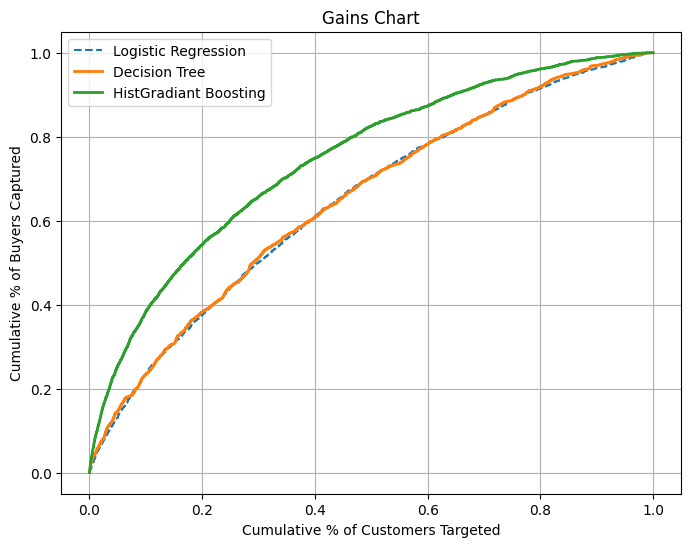

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

# Logistic Regression (Baseline)
plt.plot(
    df_logreg["cum_population_pct"],
    df_logreg["cum_positive_pct"],
    label="Logistic Regression",
    linestyle="--",
)

# Decision Tree Gains Curve
plt.plot(
    df_dtree["cum_population_pct"],
    df_dtree["cum_positive_pct"],
    label="Decision Tree",
    linewidth=2
)


# HistGradiantBoosting Gains Curve
plt.plot(
    df_hgb["cum_population_pct"],
    df_hgb["cum_positive_pct"],
    label="HistGradiant Boosting",
    linewidth=2
)

plt.xlabel("Cumulative % of Customers Targeted")
plt.ylabel("Cumulative % of Buyers Captured")
plt.title("Gains Chart")
plt.legend()
plt.grid(True)
plt.show()
